In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.linear_model import LassoCV
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import warnings
warnings.filterwarnings('ignore')

In [2]:
url = "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
                'acceleration', 'model_year', 'origin', 'car_name']
df = pd.read_csv(url, delim_whitespace=True, names=column_names)
print(df.head())

    mpg  cylinders  displacement horsepower  weight  acceleration  model_year  \
0  18.0          8         307.0      130.0  3504.0          12.0          70   
1  15.0          8         350.0      165.0  3693.0          11.5          70   
2  18.0          8         318.0      150.0  3436.0          11.0          70   
3  16.0          8         304.0      150.0  3433.0          12.0          70   
4  17.0          8         302.0      140.0  3449.0          10.5          70   

   origin                   car_name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [4]:
df['horsepower'].unique()

array(['130.0', '165.0', '150.0', '140.0', '198.0', '220.0', '215.0',
       '225.0', '190.0', '170.0', '160.0', '95.00', '97.00', '85.00',
       '88.00', '46.00', '87.00', '90.00', '113.0', '200.0', '210.0',
       '193.0', '?', '100.0', '105.0', '175.0', '153.0', '180.0', '110.0',
       '72.00', '86.00', '70.00', '76.00', '65.00', '69.00', '60.00',
       '80.00', '54.00', '208.0', '155.0', '112.0', '92.00', '145.0',
       '137.0', '158.0', '167.0', '94.00', '107.0', '230.0', '49.00',
       '75.00', '91.00', '122.0', '67.00', '83.00', '78.00', '52.00',
       '61.00', '93.00', '148.0', '129.0', '96.00', '71.00', '98.00',
       '115.0', '53.00', '81.00', '79.00', '120.0', '152.0', '102.0',
       '108.0', '68.00', '58.00', '149.0', '89.00', '63.00', '48.00',
       '66.00', '139.0', '103.0', '125.0', '133.0', '138.0', '135.0',
       '142.0', '77.00', '62.00', '132.0', '84.00', '64.00', '74.00',
       '116.0', '82.00'], dtype=object)

In [5]:
df['origin'].unique()

array([1, 3, 2], dtype=int64)

In [6]:
df['model_year'].unique()

array([70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82], dtype=int64)

In [7]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


horsepower has a missing value ?  
cylinders  is a cat variables   
what is dispacement?   
model_year is a cat variable?  
what is origin?  

#### Data Cleaning

In [8]:
# handling missing horse power values(filling with meadian)
df['horsepower'] = df['horsepower'].replace('?', np.nan)
df['horsepower'] = pd.to_numeric(df['horsepower'])
median_hp = df['horsepower'].median()
df['horsepower'].fillna(median_hp, inplace=True)

In [9]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.304020,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.222625,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [10]:
# dropping car names(non-predictive)
df.drop('car_name', axis = 1, inplace = True)

#### EDA

##### pairplot

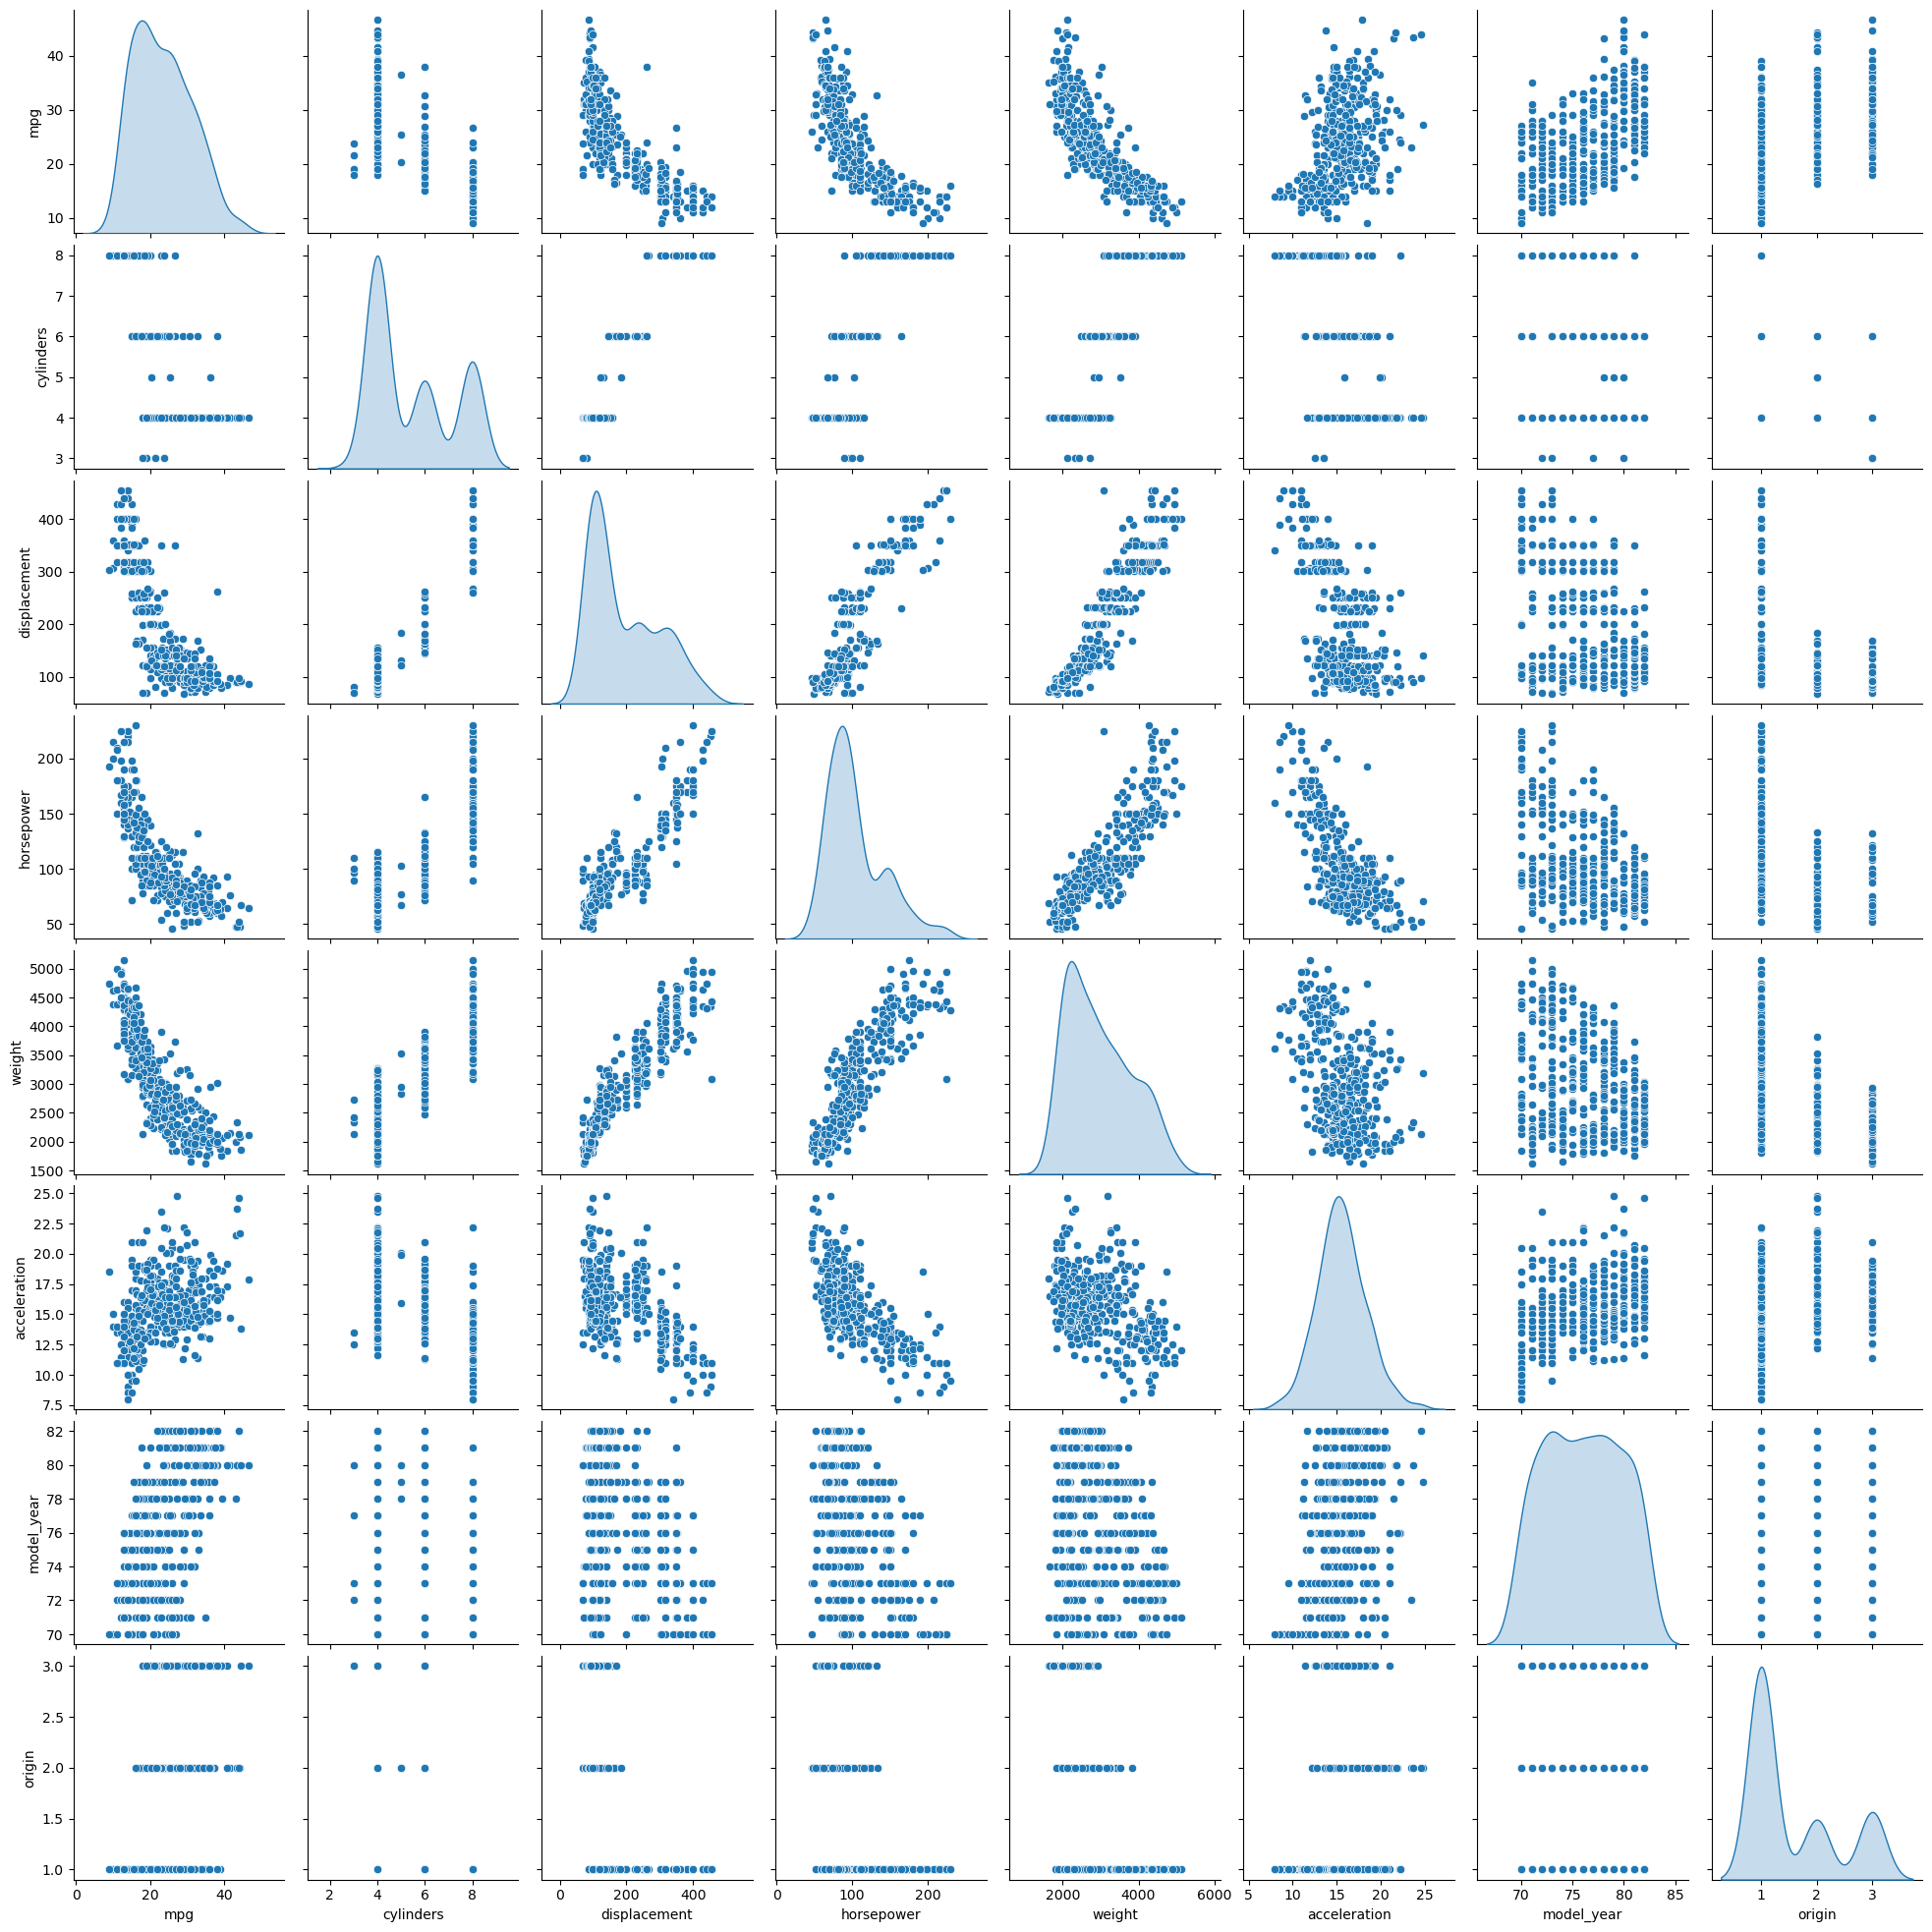

In [11]:
sns.pairplot(df, diag_kind='kde')
plt.show()

- mpg is strongly negative with weight, displacement, cylinders
- slight curvative in mpg VS horsepower and weight

##### Correlation heatmap

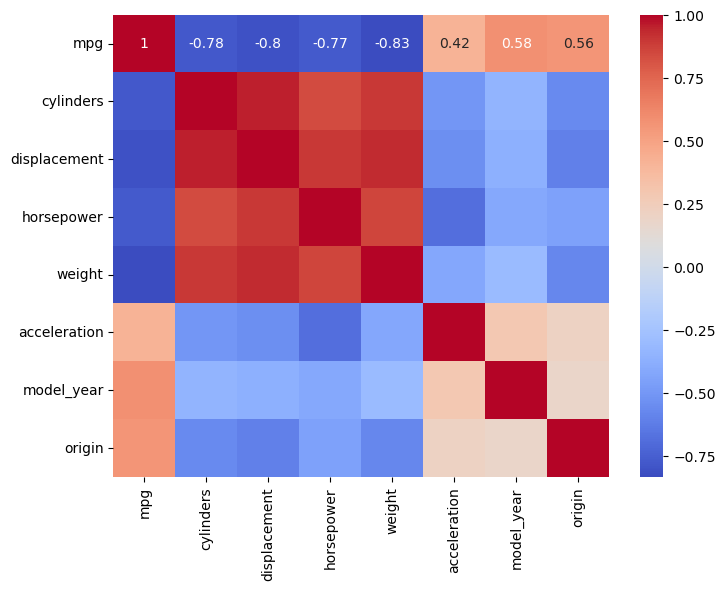

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [13]:
df.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
mpg,1.000000,-0.775396,-0.804203,-0.773453,-0.831741,0.420289,0.579267,0.563450
cylinders,-0.775396,1.000000,0.950721,0.841284,0.896017,-0.505419,-0.348746,-0.562543
displacement,-0.804203,0.950721,1.000000,0.895778,0.932824,-0.543684,-0.370164,-0.609409
horsepower,-0.773453,0.841284,0.895778,1.000000,0.862442,-0.686590,-0.413733,-0.452096
weight,-0.831741,0.896017,0.932824,0.862442,1.000000,-0.417457,-0.306564,-0.581024
acceleration,0.420289,-0.505419,-0.543684,-0.686590,-0.417457,1.000000,0.288137,0.205873
model_year,0.579267,-0.348746,-0.370164,-0.413733,-0.306564,0.288137,1.000000,0.180662
origin,0.563450,-0.562543,-0.609409,-0.452096,-0.581024,0.205873,0.180662,1.000000


##### target distribution

<Axes: xlabel='mpg', ylabel='Count'>

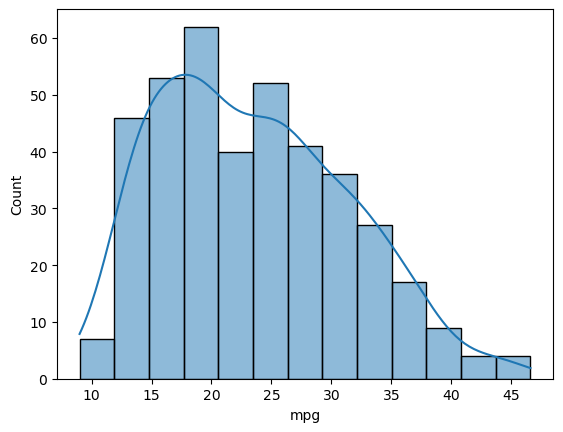

In [14]:
sns.histplot(df['mpg'], kde=True)

a bit right-skewed

#### Preprocessing pipeline

In [15]:
X = df.drop('mpg', axis=1)
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# numeric features to scale
numeric_features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
# categorical feature to one-hot encode (origin has 3 possible values)
categorical_features = ['origin']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)  # drop first to avoid dummy trap
    ])

#### Training the model

In [16]:
lr_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['cylinders', 'displacement',
                                                   'horsepower', 'weight',
                                                   'acceleration',
                                                   'model_year']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['origin'])])),
                ('regressor', LinearRegression())])

#### Model Evaluation

In [17]:
y_pred = lr_pipe.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.2f} mpg")
print(f"MAE: {mae:.2f} mpg")

R²: 0.845
RMSE: 2.89 mpg
MAE: 2.29 mpg


#### Model Interpretation

In [18]:
# after fitting, the preprocessor has the column transformer
preprocessed_feature_names = (numeric_features + 
    list(lr_pipe.named_steps['preprocessor']
         .named_transformers_['cat']
         .get_feature_names_out(categorical_features)))

coefficients = lr_pipe.named_steps['regressor'].coef_
coef_df = pd.DataFrame({'Feature': preprocessed_feature_names, 'Coefficient': coefficients})
print(coef_df)

        Feature  Coefficient
0     cylinders    -0.278695
1  displacement     2.033373
2    horsepower    -0.539182
3        weight    -5.914735
4  acceleration     0.187514
5    model_year     2.971431
6      origin_2     2.946907
7      origin_3     2.671126


#### Regularization

In [19]:
# Ridge (L2)
ridge_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])
ridge_pipe.fit(X_train, y_train)
y_pred_ridge = ridge_pipe.predict(X_test)
print("Ridge R²:", r2_score(y_test, y_pred_ridge))

# Lasso (L1)
lasso_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=0.1, max_iter=10000))
])
lasso_pipe.fit(X_train, y_train)
y_pred_lasso = lasso_pipe.predict(X_test)
print("Lasso R²:", r2_score(y_test, y_pred_lasso))

Ridge R²: 0.844740597541469
Lasso R²: 0.837560541419246


In [20]:
lasso_model = lasso_pipe.named_steps['regressor']
print("Iterations performed:", lasso_model.n_iter_)
print("Duality gap:", lasso_model.dual_gap_)

Iterations performed: 47
Duality gap: 0.0005026201873067677


In [21]:
preprocessor = lr_pipe.named_steps['preprocessor']

# Numeric features 
numeric_features = ['cylinders', 'displacement', 'horsepower', 'weight', 
                    'acceleration', 'model_year']

# One-hot encoded feature names (drop='first' so we eliminated one dummy)
cat_feature_names = preprocessor.named_transformers_['cat'] \
                              .get_feature_names_out(['origin'])

# Full list in order
all_features = numeric_features + list(cat_feature_names)

##### Extracting coefficients from each model

In [22]:
# Linear Regression
coef_lr = lr_pipe.named_steps['regressor'].coef_

# Ridge
coef_ridge = ridge_pipe.named_steps['regressor'].coef_

# Lasso
coef_lasso = lasso_pipe.named_steps['regressor'].coef_

In [23]:
# comparison dataframe
coef_comparison = pd.DataFrame({
    'Feature': all_features,
    'LinearReg': coef_lr,
    'Ridge':     coef_ridge,
    'Lasso':     coef_lasso
})

# round for readability
coef_comparison = coef_comparison.round(4)
print(coef_comparison)

        Feature  LinearReg   Ridge   Lasso
0     cylinders    -0.2787 -0.2175 -0.0000
1  displacement     2.0334  1.6885 -0.0000
2    horsepower    -0.5392 -0.5535 -0.0992
3        weight    -5.9147 -5.6945 -5.1872
4  acceleration     0.1875  0.1448  0.0197
5    model_year     2.9714  2.9397  2.7951
6      origin_2     2.9469  2.7501  1.0788
7      origin_3     2.6711  2.5196  0.9653


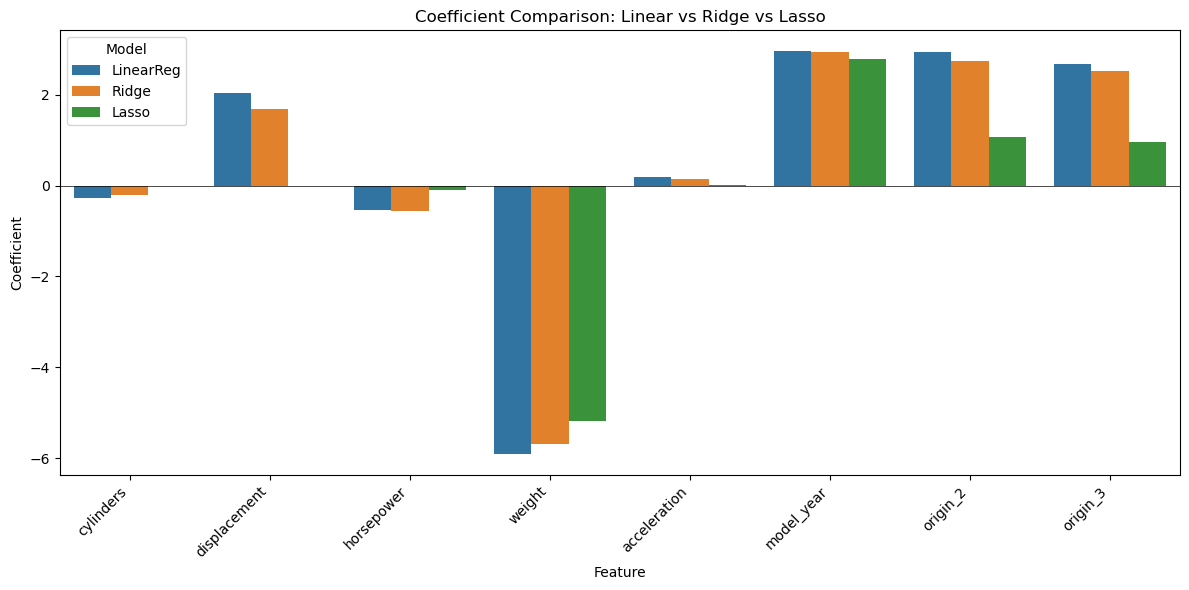

In [24]:
coef_melted = coef_comparison.melt(id_vars='Feature', 
                                   var_name='Model', value_name='Coefficient')

plt.figure(figsize=(12, 6))
sns.barplot(data=coef_melted, x='Feature', y='Coefficient', hue='Model')
plt.xticks(rotation=45, ha='right')
plt.title('Coefficient Comparison: Linear vs Ridge vs Lasso')
plt.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

In [25]:
lasso_survivors = coef_comparison[coef_comparison['Lasso'] != 0]['Feature']
print("Lasso kept these features:")
print(lasso_survivors.tolist())

Lasso kept these features:
['horsepower', 'weight', 'acceleration', 'model_year', 'origin_2', 'origin_3']


In [26]:
# LassoCV within the pipeline ( tuning the regressor's alpha)
lasso_cv_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LassoCV(cv=5, max_iter=10000, random_state=42))
])

lasso_cv_pipe.fit(X_train, y_train)

# Best alpha and coefficients
best_alpha = lasso_cv_pipe.named_steps['regressor'].alpha_
coef_tuned = lasso_cv_pipe.named_steps['regressor'].coef_

print(f"Best alpha: {best_alpha:.3f}")
r2_tuned_lasso = lasso_cv_pipe.score(X_test, y_test)
print(f"Tuned Lasso (alpha={best_alpha:.3f}) R²: {r2_tuned_lasso:.3f}")
pd.DataFrame({'Feature': all_features, 'Coefficient': coef_tuned})

Best alpha: 0.013
Tuned Lasso (alpha=0.013) R²: 0.843


,Feature,Coefficient
0,cylinders,-0.000000
1,displacement,1.324731
2,horsepower,-0.404882
3,weight,-5.725437
4,acceleration,0.156281
5,model_year,2.941368
6,origin_2,2.600985
7,origin_3,2.346633


In [27]:
models = {
    'Linear Regression': lr_pipe,
    'Ridge (alpha=1)': ridge_pipe,
    'Lasso (alpha=0.1)': lasso_pipe,
    'Lasso (tuned=0.013)': lasso_cv_pipe   
}

results = []
for name, pipe in models.items():
    preds = pipe.predict(X_test)
    results.append({
        'Model': name,
        'R²': r2_score(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE': mean_absolute_error(y_test, preds)
    })

results_df = pd.DataFrame(results).round(3)
print(results_df)

                 Model     R²   RMSE    MAE
0    Linear Regression  0.845  2.888  2.288
1      Ridge (alpha=1)  0.845  2.889  2.288
2    Lasso (alpha=0.1)  0.838  2.955  2.343
3  Lasso (tuned=0.013)  0.843  2.908  2.294


#### Takeaways

- Ridge doesn`t hurt - nor help(ridge regularization show virtually identical metrics as plain lr)
- Lasso with alpha=0.1 was too aggressive(lower R² with higher errors). it forced some coefficients down too much, losing predictive power.
- Tuned Lasso recovers almost all performance

#### Residual analysis

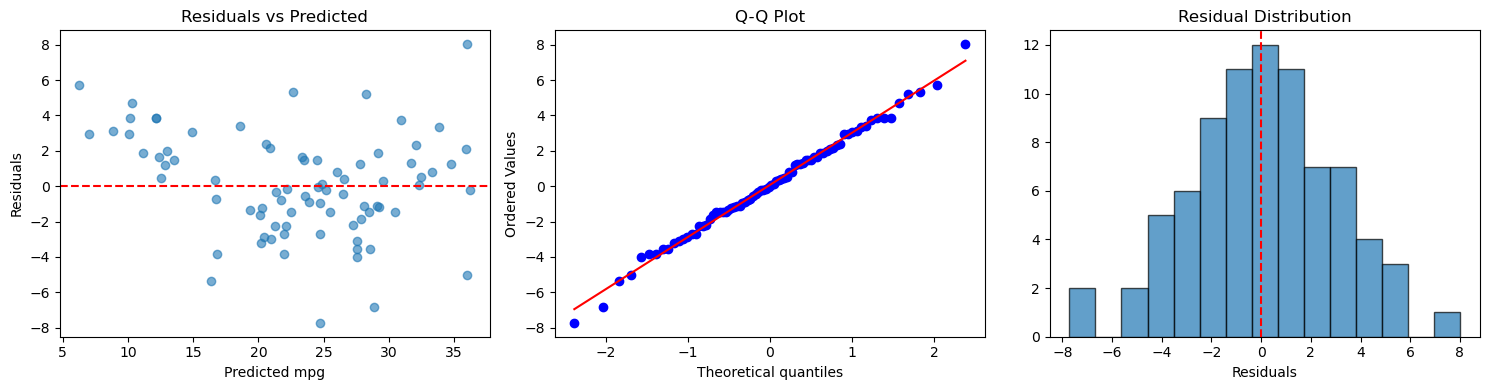

In [28]:
residuals = y_test - lr_pipe.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Residuals vs predicted
axes[0].scatter(lr_pipe.predict(X_test), residuals, alpha=0.6)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted mpg')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

# 2. Q-Q plot
from scipy import stats
stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot')

# 3. Histogram of residuals
axes[2].hist(residuals, bins=15, edgecolor='k', alpha=0.7)
axes[2].axvline(x=0, color='r', linestyle='--')
axes[2].set_xlabel('Residuals')
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

- The model is consistently under-predicting for lower mpg values. This suggests the relationship between variables might be slightly curved. Adding a polynomial term or performing a log transformation on the features might be beneficial.
- Homoscedasticity: vertical spread of the dots is relatively consistent(model satisfies the assumption of constant variance)

In [29]:
X_train

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
3,8,304.0,150.0,3433.0,12.0,70,1
18,4,97.0,88.0,2130.0,14.5,70,3
376,4,91.0,68.0,2025.0,18.2,82,3
248,4,91.0,60.0,1800.0,16.4,78,3
177,4,115.0,95.0,2694.0,15.0,75,2
...,...,...,...,...,...,...,...
71,3,70.0,97.0,2330.0,13.5,72,3
106,8,350.0,180.0,4499.0,12.5,73,1
270,4,134.0,95.0,2515.0,14.8,78,3
348,4,89.0,62.0,2050.0,17.3,81,3


In [30]:
# numeric columns only (categorical dummies not appropriate for VIF)
# Use the raw X_train before scaling, but with dummies added
X_vif = X_train.copy()
X_vif['origin_2'] = (X_vif['origin'] == 2).astype(int)
X_vif['origin_3'] = (X_vif['origin'] == 3).astype(int)
X_vif = X_vif.drop('origin', axis=1)  # drop original categorical

# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)

        Feature         VIF
0     cylinders  120.383940
1  displacement  101.902690
2    horsepower   63.547416
3        weight  134.530033
4  acceleration   67.792000
5    model_year  108.826532
6      origin_2    1.959200
7      origin_3    2.288997


The  numeric features (cylinders, displacement, horsepower, weight, acceleration, model_year) are highly collinear.
VIFs are astronomical, meaning predictors are highly correlated, coefficients are unstable, interpretations unreliable.

In [31]:
cv_scores = cross_val_score(lr_pipe, X, y, cv=5, scoring='r2')
print(f"Cross-validated R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Individual fold R²: {cv_scores.round(3)}")

Cross-validated R²: 0.594 ± 0.198
Individual fold R²: [0.568 0.687 0.809 0.679 0.229]


Cross-validation shows that model's performance is highly variable and poor on some folds(e.g.R² = 0.229). This means the model doesn't generalize well

#### Posssible Solutions:
- Dimensionality reduction (PCA)
- Droping highly correlated features
- We should probably run cross-validation on Ridge and Lasso to see if they stabilize performance

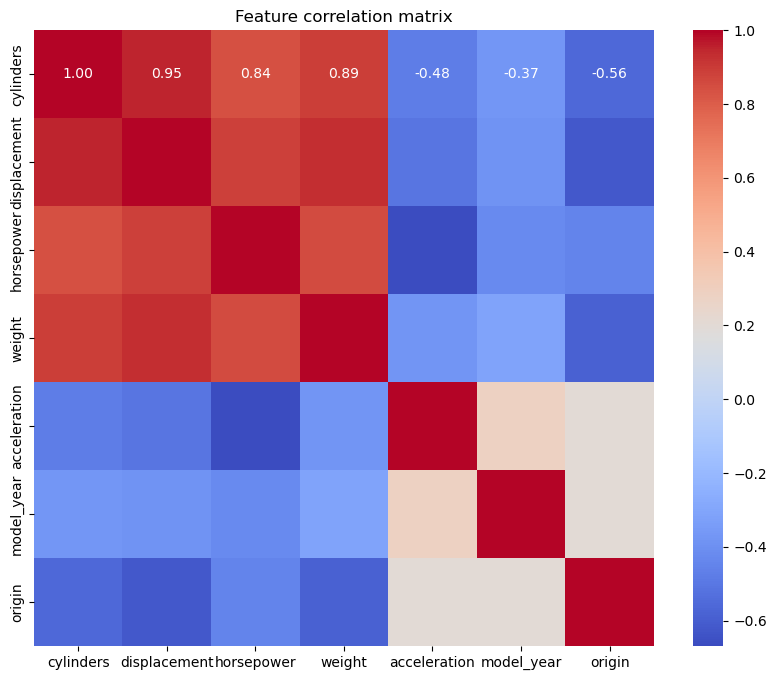

In [31]:
# Compute correlation on the scaled numeric training data (or raw, it's fine)
corr = X_train.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature correlation matrix')
plt.show()

In [32]:
corr

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
cylinders,1.000000,0.951825,0.837407,0.893808,-0.479743,-0.372146,-0.562782
displacement,0.951825,1.000000,0.887164,0.929479,-0.512604,-0.384505,-0.620072
horsepower,0.837407,0.887164,1.000000,0.852582,-0.669442,-0.427542,-0.449212
weight,0.893808,0.929479,0.852582,1.000000,-0.380938,-0.313227,-0.585384
acceleration,-0.479743,-0.512604,-0.669442,-0.380938,1.000000,0.286697,0.203643
model_year,-0.372146,-0.384505,-0.427542,-0.313227,0.286697,1.000000,0.198992
origin,-0.562782,-0.620072,-0.449212,-0.585384,0.203643,0.198992,1.000000


cylinders feature is highly correlated with displacement and weight and displacement.
Let`s keep weight, acceleration, model_year and origin first and look at results

In [34]:
# Select columns
reduced_features = ['weight', 'acceleration', 'model_year', 'origin']

X_reduced = X[reduced_features]  # original DataFrame, before scaling
y = df['mpg']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

# Preprocessor for numeric + categorical
numeric_features_r = ['weight', 'acceleration', 'model_year']
categorical_features_r = ['origin']

preprocessor_r = ColumnTransformer([
    ('num', StandardScaler(), numeric_features_r),
    ('cat', OneHotEncoder(drop='first'), categorical_features_r)
])

lr_pipe_r = Pipeline([
    ('preprocessor', preprocessor_r),
    ('regressor', LinearRegression())
])

lr_pipe_r.fit(X_train_r, y_train_r)

# Predict & score
y_pred_r = lr_pipe_r.predict(X_test_r)
print("Reduced model R²:", r2_score(y_test_r, y_pred_r))
print("RMSE:", np.sqrt(mean_squared_error(y_test_r, y_pred_r)))

Reduced model R²: 0.8385298680293942
RMSE: 2.946468185455708


In [46]:
# Compute VIF on the continuous-only training data (no dummies)
X_vif_r = X_train_r[['weight', 'acceleration', 'model_year']]
X_vif_r_const = add_constant(X_vif_r)
vif_r = pd.DataFrame({
    'Feature': X_vif_r.columns,
    'VIF': [variance_inflation_factor(X_vif_r_const.values, i+1) for i in range(X_vif_r.shape[1])]
})
print(vif_r)

        Feature       VIF
0        weight  1.235273
1  acceleration  1.213852
2    model_year  1.150591


In [36]:
cv_scores_r = cross_val_score(lr_pipe_r, X_reduced, y, cv=5, scoring='r2')
print(f"Reduced model CV R²: {cv_scores_r.mean():.3f} ± {cv_scores_r.std():.3f}")
print("Fold scores:", cv_scores_r.round(3))

Reduced model CV R²: 0.594 ± 0.203
Fold scores: [0.551 0.712 0.811 0.673 0.223]


In [37]:
cv_ridge = cross_val_score(ridge_pipe, X, y, cv=5, scoring='r2')
print(f"Ridge CV R²: {cv_ridge.mean():.3f} ± {cv_ridge.std():.3f}")

Ridge CV R²: 0.593 ± 0.204


In [38]:
cv_lasso_tuned = cross_val_score(lasso_cv_pipe, X, y, cv=5, scoring='r2')
print(f"Tuned Lasso CV R²: {cv_lasso_tuned.mean():.3f} ± {cv_lasso_tuned.std():.3f}")

Tuned Lasso CV R²: 0.566 ± 0.254


In [39]:
print(X_train_r[['weight', 'acceleration', 'model_year']].corr())

                weight  acceleration  model_year
weight        1.000000     -0.380938   -0.313227
acceleration -0.380938      1.000000    0.286697
model_year   -0.313227      0.286697    1.000000


embracing ridge

In [40]:
ridge_cv_pipe = Pipeline([
    ('preprocessor', preprocessor_r),
    ('regressor', RidgeCV(alphas=[0.1, 1, 10, 100, 500, 1000], cv=5))
])
ridge_cv_pipe.fit(X_train_r, y_train_r)
print("Best alpha:", ridge_cv_pipe.named_steps['regressor'].alpha_)
print("Train R²:", ridge_cv_pipe.score(X_train_r, y_train_r))
print("Test R²:", ridge_cv_pipe.score(X_test_r, y_test_r))

Best alpha: 10.0
Train R²: 0.8138870315407969
Test R²: 0.8420703456483125


In [41]:
cv_ridge_tuned = cross_val_score(ridge_cv_pipe, X_reduced, y, cv=5, scoring='r2')
print(f"Tuned Ridge CV R²: {cv_ridge_tuned.mean():.3f} ± {cv_ridge_tuned.std():.3f}")

Tuned Ridge CV R²: 0.597 ± 0.218


Conclusion:
Performance of the model varied drastically across folds, indicating that the model is highly sensitive ti the data split due to multicollinearity and limited sample size.
Yet model still captures the major trends and would likely be stable on a larger, more diverse dataset

In [42]:
import statsmodels.api as sm

# Predict acceleration from weight and model_year
X_vif_check = sm.add_constant(X_train_r[['weight', 'model_year']])
model_check = sm.OLS(X_train_r['acceleration'], X_vif_check).fit()
r_squared = model_check.rsquared
vif_equivalent = 1 / (1 - r_squared)
print(f"R² for acceleration ~ weight + model_year: {r_squared:.3f}")
print(f"That gives VIF = {vif_equivalent:.1f}")

R² for acceleration ~ weight + model_year: 0.176
That gives VIF = 1.2


In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Assuming X_train_r contains all your predictors (including weight, model_year, acceleration)
# Ensure a constant is added for the calculation
X = sm.add_constant(X_train_r[['weight', 'model_year', 'acceleration']])

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

        feature         VIF
0         const  573.156227
1        weight    1.235273
2    model_year    1.150591
3  acceleration    1.213852


Let`s check if dataset sorted y year, origin or some other structure that makes certain folds widly unrepresentative

In [43]:
# Look at the distribution of model_year across the whole dataset
print("Model year distribution:")
print(df['model_year'].value_counts().sort_index())

# Check if data is ordered somehow
print("\nFirst 10 rows of original df:")
print(df[['weight', 'model_year', 'origin']].head(10))
print("\nLast 10 rows:")
print(df[['weight', 'model_year', 'origin']].tail(10))

Model year distribution:
model_year
70    29
71    28
72    28
73    40
74    27
75    30
76    34
77    28
78    36
79    29
80    29
81    29
82    31
Name: count, dtype: int64

First 10 rows of original df:
   weight  model_year  origin
0  3504.0          70       1
1  3693.0          70       1
2  3436.0          70       1
3  3433.0          70       1
4  3449.0          70       1
5  4341.0          70       1
6  4354.0          70       1
7  4312.0          70       1
8  4425.0          70       1
9  3850.0          70       1

Last 10 rows:
     weight  model_year  origin
388  2585.0          82       1
389  2835.0          82       1
390  2665.0          82       3
391  2370.0          82       1
392  2950.0          82       1
393  2790.0          82       1
394  2130.0          82       2
395  2295.0          82       1
396  2625.0          82       1
397  2720.0          82       1


The dataset grouped by model_year(and within that by origin)

To try to fix it let`s shuffle cv folds using Kfold

In [45]:
# Shuffled KFold with fixed random state
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_ridge_shuffled = cross_val_score(ridge_cv_pipe, X_reduced, y, cv=kf, scoring='r2')
print(f"Shuffled Ridge CV R²: {cv_ridge_shuffled.mean():.3f} ± {cv_ridge_shuffled.std():.3f}")
print(f"Fold scores: {cv_ridge_shuffled.round(3)}")

Shuffled Ridge CV R²: 0.813 ± 0.023
Fold scores: [0.842 0.816 0.834 0.782 0.792]


to conform let`s also startify by model_year bins

In [46]:
# Create year bins
year_bins = pd.cut(y.index.map(lambda i: df.loc[i, 'model_year']), bins=5)

# Not directly usable as labels, so we use StratifiedKFold with the target
# But for regression, we can bin the target (mpg) into categories
y_binned = pd.cut(y, bins=5, labels=False)

from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_stratified = cross_val_score(ridge_cv_pipe, X_reduced, y, cv=skf.split(X_reduced, y_binned), scoring='r2')
print(f"Stratified Ridge CV R²: {cv_stratified.mean():.3f} ± {cv_stratified.std():.3f}")

Stratified Ridge CV R²: 0.814 ± 0.019


Initial OLS gave R²=0.845 on a single split, but cross-validation revealed R² dropping with high variance. Investigation showed:

- multicollinearity from feature combinations(VIF up to 64, despite pairwise correlation  < 0.4)
- temporal ordering in the dataset causing train/test distribution shift. After shuffling cross-validation folds and applying Ridge regularization (alpha=10), the model achieved a stable R² of 0.81 ± 0.02.